# Expressivity of physical SYNE-KANs

This notebook reproduces the expressivity analysis used in *Learning Nonlinear Heterogeneity in Physical Kolmogorov-Arnold Networks*.

The workflow is:

1. generate conditioned response-curve ensembles for `[1,1]` and `[1,1,1]` physical SYNE-KANs;
2. normalise each curve to its shape on `[-1,1]`;
3. fit one shared PCA basis across every configuration;
4. measure the reachable-set geometry using $\epsilon$-packing, including $\epsilon_{50}$.

The notebook keeps the analysis self-contained. It requires only the released SYNE device digital twin and the standard scientific Python packages used by the other repository notebooks.

## Before running

Place `SYNE_device_digital_twin_B.pt` beside the notebook, or set `SYNE_TWIN_PATH` to its location.

The paper settings generate 2,000 curves for every architecture / SYNE-count configuration. The shared PCA basis depends on the complete set of configurations included in the run, so $\epsilon_{50}$ values should only be compared within a common run.

In [1]:
from __future__ import annotations

import csv
import json
import os
import re
import sys
import time
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")

PLOT_DPI = 240
GRID_ALPHA = 0.22

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
    }
)


def save_figure(fig, path, dpi=PLOT_DPI):
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")


print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__} | device: {DEVICE}")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python 3.7.16 | PyTorch 1.13.1 | device: cuda
GPU: NVIDIA GeForce RTX 4080


## Run configuration

`SYNE_COUNTS` controls the configurations generated and analysed. `PLOT_SYNE_COUNTS` selects the subset shown in the packing figures, while `FIT_SYNE_COUNTS` selects the subset used for the scaling fits.

Each configuration contributes the same number of curves to the shared PCA pool.

In [2]:
# -----------------------------------------------------------------------------
# USER SETTINGS
# -----------------------------------------------------------------------------

PROJECT_ROOT = Path.cwd()
TWIN_PATH = Path(
    os.environ.get("SYNE_TWIN_PATH", PROJECT_ROOT / "SYNE_device_digital_twin_B.pt")
).expanduser()
RESULTS_ROOT = Path(
    os.environ.get("SYNE_RESULTS_DIR", PROJECT_ROOT / "results_expressivity_release")
).expanduser()

ARCHITECTURES = [[1, 1], [1, 1, 1]]
SYNE_COUNTS = [1, 2, 3, 4, 5, 6, 8]
PLOT_SYNE_COUNTS = [1, 2, 3, 5, 8]
FIT_SYNE_COUNTS = [2, 3, 4, 6, 8]

CURVES_PER_CONFIGURATION = 2_000
N_INPUT_POINTS = 600
INPUT_MIN_V = -2.0
INPUT_MAX_V = 2.0

CURVE_NORMALISATION = "minmax"
PCA_RANK = 32
PCA_CURVES_PER_CONFIGURATION = 600
PACKING_RESTARTS = 6
N_EPSILON = 220
HIGH_PACKING_FRACTION = 0.95
SOFT_DIAMETER_TAU = 0.25
EPS50_BISECTION_STEPS = 22

GENERATION_SEED = 1234
PCA_SEED = 123
PACKING_SEED = 0

OUTPUT_ROOT = RESULTS_ROOT
CURVE_ROOT = OUTPUT_ROOT / "curves"
TABLE_ROOT = OUTPUT_ROOT / "tables"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
ARRAY_ROOT = OUTPUT_ROOT / "arrays"
for path in (OUTPUT_ROOT, CURVE_ROOT, TABLE_ROOT, FIGURE_ROOT, ARRAY_ROOT):
    path.mkdir(parents=True, exist_ok=True)

print("Digital twin:", TWIN_PATH)
print("Results:", OUTPUT_ROOT)
print("Architectures:", ARCHITECTURES)
print("SYNEs per synapse:", SYNE_COUNTS)
print("Curves per configuration:", CURVES_PER_CONFIGURATION)

Digital twin: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\DaCleanOnes\SYNE_device_digital_twin_B.pt
Results: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\DaCleanOnes\results_expressivity_release
Architectures: [[1, 1], [1, 1, 1]]
SYNEs per synapse: [1, 2, 3, 4, 5, 6, 8]
Curves per configuration: 2000


## SYNE device digital twin

The released checkpoint stores the frozen SYNE device model together with its input and output normalisation scales. The expressivity pipeline uses those scales to convert the voltage sweep and control-voltage draws into the normalised coordinates seen by the twin.

The loader also accepts the older tuple checkpoint format and compatible state dictionaries.

In [3]:
class RebuiltTwin(nn.Module):
    """Compatibility wrapper for a checkpoint containing only an MLP state_dict."""

    def __init__(self, weights, biases):
        super().__init__()
        self.weights = nn.ParameterList(
            [nn.Parameter(weight.clone(), requires_grad=False) for weight in weights]
        )
        self.biases = nn.ParameterList(
            [nn.Parameter(bias.clone(), requires_grad=False) for bias in biases]
        )

    def forward(self, x):
        for layer, (weight, bias) in enumerate(zip(self.weights, self.biases)):
            x = F.linear(x, weight, bias)
            if layer + 1 < len(self.weights):
                x = F.relu(x)
        return x


def _natural_key(name: str):
    return [int(part) if part.isdigit() else part for part in re.split(r"(\d+)", name)]


def _strip_prefix(text: str, prefix: str) -> str:
    return text[len(prefix):] if text.startswith(prefix) else text


def _torch_load_compat(path: Path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def _rebuild_twin_from_state(state: dict) -> nn.Module:
    cleaned_state = {}
    for key, value in state.items():
        key = _strip_prefix(str(key), "module.")
        key = _strip_prefix(key, "model.")
        cleaned_state[key] = value

    weight_keys = sorted(
        [
            key for key, value in cleaned_state.items()
            if key.endswith("weight") and getattr(value, "ndim", 0) == 2
        ],
        key=_natural_key,
    )
    if not weight_keys:
        raise ValueError("No two-dimensional linear weights were found in the twin checkpoint")

    weights, biases = [], []
    for key in weight_keys:
        weight = cleaned_state[key].float()
        bias_key = key[:-6] + "bias"
        bias = cleaned_state.get(bias_key, torch.zeros(weight.shape[0])).float()
        weights.append(weight)
        biases.append(bias)
    return RebuiltTwin(weights, biases)


def load_frozen_twin(path: Path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"Digital twin not found: {path}\n"
            "Place SYNE_device_digital_twin.pt beside the notebook, set TWIN_PATH, "
            "or define the SYNE_TWIN_PATH environment variable."
        )

    payload = _torch_load_compat(path)
    input_scale = None
    output_scale = None

    if isinstance(payload, dict):
        if isinstance(payload.get("model"), nn.Module):
            twin = payload["model"]
        else:
            state = payload.get("model_state_dict", payload.get("state_dict", payload))
            if not isinstance(state, dict):
                raise TypeError(f"Unsupported twin checkpoint payload: {type(payload)}")
            twin = _rebuild_twin_from_state(state)
        input_scale = payload.get("x_scale")
        output_scale = payload.get("y_scale")
    elif isinstance(payload, (list, tuple)) and payload and isinstance(payload[0], nn.Module):
        twin = payload[0]
        if len(payload) > 1:
            input_scale = payload[1]
        if len(payload) > 2:
            output_scale = payload[2]
    elif isinstance(payload, nn.Module):
        twin = payload
    else:
        raise TypeError(f"Unsupported twin checkpoint payload: {type(payload)}")

    if input_scale is None or output_scale is None:
        raise ValueError(
            "The expressivity pipeline requires x_scale and y_scale in the twin checkpoint."
        )

    twin = twin.to(DEVICE).float().eval()
    for parameter in twin.parameters():
        parameter.requires_grad_(False)

    input_scale = torch.as_tensor(input_scale, dtype=torch.float32).view(-1).cpu().numpy()
    output_scale = float(torch.as_tensor(output_scale, dtype=torch.float32).view(-1)[0].item())

    if input_scale.size == 1:
        signal_scale = control_1_scale = control_2_scale = float(input_scale[0])
    else:
        signal_scale, control_1_scale, control_2_scale = map(float, input_scale[:3])

    print(f"Loaded and froze {path.name} ({type(twin).__name__})")
    return twin, signal_scale, control_1_scale, control_2_scale, output_scale


TWIN, SIGNAL_SCALE_V, CONTROL_1_SCALE_V, CONTROL_2_SCALE_V, OUTPUT_SCALE = load_frozen_twin(TWIN_PATH)

INPUT_SWEEP_V = np.linspace(INPUT_MIN_V, INPUT_MAX_V, N_INPUT_POINTS).astype(np.float32)
INPUT_SWEEP_TENSOR = (
    torch.tensor(INPUT_SWEEP_V, device=DEVICE) / float(SIGNAL_SCALE_V)
).view(-1, 1)

print(f"Signal scale: {SIGNAL_SCALE_V:.4f} V")
print(f"Control scales: {CONTROL_1_SCALE_V:.4f} V, {CONTROL_2_SCALE_V:.4f} V")
print(f"Output scale: {OUTPUT_SCALE:.4e}")
print(
    f"Input sweep: {INPUT_MIN_V:+.2f} to {INPUT_MAX_V:+.2f} V "
    f"-> normalised |x| <= {np.abs(INPUT_SWEEP_V).max() / SIGNAL_SCALE_V:.4f}"
)

Loaded and froze SYNE_device_digital_twin_B.pt (Sequential)
Signal scale: 1.9200 V
Control scales: 1.9200 V, 1.9200 V
Output scale: 1.2334e-08
Input sweep: -2.00 to +2.00 V -> normalised |x| <= 1.0417


## Random physical KAN parameters

The curve ensembles use the same physical quantities as the released SYNE-KAN notebooks: signal windows, two control voltages, output gains and output biases. Control voltages are sampled in volts and converted using the checkpoint scale before they are written into the model.

In [4]:
# -----------------------------------------------------------------------------
# PARAMETER SAMPLING
# -----------------------------------------------------------------------------

CONTROL_MIN_V = -2.0
CONTROL_MAX_V = 2.0
WINDOW_SCALE_V = max(abs(INPUT_MIN_V), abs(INPUT_MAX_V))
WINDOW_DELTA_MIN_V = 1.2
S_RAW_ABS_MAX = 2.35
EFFECTIVE_ABS_MIN = float(WINDOW_DELTA_MIN_V / (2.0 * WINDOW_SCALE_V))
S_RAW_ABS_MIN = float(EFFECTIVE_ABS_MIN * S_RAW_ABS_MAX)
S_RAW_MAG_GAMMA = 1.0
OUTPUT_GAIN_CHOICES = np.array(
    [1.0, -1.0, 0.5, -0.5, 2.0, -2.0, 4.0, -4.0],
    dtype=np.float32,
)

RANGE_DISCARD_THRESHOLD = 0.02e-8
MAX_SCAN_MULTIPLIER = 80
PRINT_EVERY = 500


def inverse_squash(effective_value):
    """Invert 2*sigmoid(x)-1 for a requested effective parameter value."""
    effective_value = torch.clamp(effective_value, -0.999999, 0.999999)
    probability = torch.clamp(
        (effective_value + 1.0) * 0.5,
        1e-6,
        1.0 - 1e-6,
    )
    return torch.log(probability / (1.0 - probability))


def latin_hypercube(number_of_samples, dimensions, rng):
    """Latin-hypercube samples in [0,1]^dimensions."""
    samples = np.empty((number_of_samples, dimensions), dtype=np.float64)
    for dimension in range(dimensions):
        permutation = rng.permutation(number_of_samples)
        samples[:, dimension] = (
            permutation + rng.rand(number_of_samples)
        ) / number_of_samples
    return samples


def sample_signal_windows(number_of_samples, rng):
    samples = latin_hypercube(number_of_samples, 2, rng)
    lower_magnitude = S_RAW_ABS_MIN + (S_RAW_ABS_MAX - S_RAW_ABS_MIN) * (
        samples[:, 0] ** S_RAW_MAG_GAMMA
    )
    upper_magnitude = S_RAW_ABS_MIN + (S_RAW_ABS_MAX - S_RAW_ABS_MIN) * (
        samples[:, 1] ** S_RAW_MAG_GAMMA
    )
    return (
        (-lower_magnitude).astype(np.float32),
        (+upper_magnitude).astype(np.float32),
    )


def signal_windows_to_effective(S_min_raw, S_max_raw):
    S_min_effective = np.clip(
        S_min_raw / S_RAW_ABS_MAX,
        -0.999999,
        0.999999,
    ).astype(np.float32)
    S_max_effective = np.clip(
        S_max_raw / S_RAW_ABS_MAX,
        -0.999999,
        0.999999,
    ).astype(np.float32)
    if np.any(S_max_effective <= S_min_effective):
        raise RuntimeError("Bad signal-window ordering after normalisation")
    return S_min_effective, S_max_effective


def sample_output_gains(rng, SYNEs_per_synapse):
    return rng.choice(
        OUTPUT_GAIN_CHOICES,
        size=int(SYNEs_per_synapse),
        replace=True,
    ).astype(np.float32)


def _repeat_to_length(values, target_length):
    values = values.view(-1)
    if values.numel() == target_length:
        return values
    repeats = (target_length + values.numel() - 1) // values.numel()
    return values.repeat(repeats)[:target_length]


def bind_parameter_views(model):
    """Return flat parameter views used when repeatedly resampling a model."""
    V_flat = []
    S_min_flat = []
    S_max_flat = []
    G_o_flat = []
    B_o_flat = []
    for layer in range(len(model.V)):
        V_flat.append(model.V[layer].reshape(-1, model.controls))
        S_min_flat.append(model.S_min[layer].reshape(-1))
        S_max_flat.append(model.S_max[layer].reshape(-1))
        G_o_flat.append(model.G_o[layer].reshape(-1))
        B_o_flat.append(model.B_o[layer].reshape(-1))
    return V_flat, S_min_flat, S_max_flat, G_o_flat, B_o_flat


def write_random_configuration(
    parameter_views,
    rng,
    n_layers,
    SYNEs_per_synapse,
    control_1_scale,
    control_2_scale,
):
    """Write one random physical-KAN parameter draw into the existing model."""
    V_flat, S_min_flat, S_max_flat, G_o_flat, B_o_flat = parameter_views

    V1 = rng.uniform(
        CONTROL_MIN_V,
        CONTROL_MAX_V,
        size=(n_layers, SYNEs_per_synapse),
    ).astype(np.float32)
    V2 = rng.uniform(
        CONTROL_MIN_V,
        CONTROL_MAX_V,
        size=(n_layers, SYNEs_per_synapse),
    ).astype(np.float32)
    output_gains = np.stack(
        [sample_output_gains(rng, SYNEs_per_synapse) for _ in range(n_layers)],
        axis=0,
    ).astype(np.float32)

    S_min_raw, S_max_raw = sample_signal_windows(
        n_layers * SYNEs_per_synapse,
        rng,
    )
    S_min_effective, S_max_effective = signal_windows_to_effective(
        S_min_raw,
        S_max_raw,
    )
    S_min_effective = S_min_effective.reshape(n_layers, SYNEs_per_synapse)
    S_max_effective = S_max_effective.reshape(n_layers, SYNEs_per_synapse)

    V1_effective = np.clip(
        V1 / float(control_1_scale),
        -0.999999,
        0.999999,
    ).astype(np.float32)
    V2_effective = np.clip(
        V2 / float(control_2_scale),
        -0.999999,
        0.999999,
    ).astype(np.float32)

    V1_raw = inverse_squash(torch.tensor(V1_effective, device=DEVICE))
    V2_raw = inverse_squash(torch.tensor(V2_effective, device=DEVICE))
    S_min_tensor = torch.tensor(S_min_effective, device=DEVICE)
    S_max_tensor = torch.tensor(S_max_effective, device=DEVICE)
    output_gain_tensor = torch.tensor(output_gains, device=DEVICE)

    for layer in range(n_layers):
        n_total = V_flat[layer].shape[0]
        V_flat[layer][:, 0].copy_(_repeat_to_length(V1_raw[layer], n_total))
        V_flat[layer][:, 1].copy_(_repeat_to_length(V2_raw[layer], n_total))
        S_min_flat[layer].copy_(_repeat_to_length(S_min_tensor[layer], n_total))
        S_max_flat[layer].copy_(_repeat_to_length(S_max_tensor[layer], n_total))
        G_o_flat[layer].copy_(_repeat_to_length(output_gain_tensor[layer], n_total))
        B_o_flat[layer].zero_()

## Physical KAN

Each synapse sums `SYNEs_per_synapse` parallel SYNE responses. `[1,1]` contains one physical KAN layer and `[1,1,1]` contains two layers in series.

For this expressivity analysis the sampled parameters are written directly into the model and then frozen; the notebook does not train the KAN.

In [5]:
class PhysicalKAN(nn.Module):
    """Constant-control SYNE-KAN using the frozen SYNE device digital twin."""

    def __init__(
        self,
        twin,
        architecture,
        SYNEs_per_synapse,
        controls=2,
        sigmoid=False,
    ):
        super().__init__()
        self.twin = twin
        self.architecture = [int(value) for value in architecture]
        self.SYNEs_per_synapse = int(SYNEs_per_synapse)
        self.controls = int(controls)
        self.sigmoid = bool(sigmoid)
        self.output_gain_scale = 50.0

        for parameter in self.twin.parameters():
            parameter.requires_grad_(False)

        self.S_min = nn.ParameterList()
        self.S_max = nn.ParameterList()
        self.V = nn.ParameterList()
        self.G_o = nn.ParameterList()
        self.B_o = nn.ParameterList()
        self.activations = []

        for n_in, n_out in zip(self.architecture[:-1], self.architecture[1:]):
            shape = (n_in, n_out, self.SYNEs_per_synapse)
            self.S_min.append(
                nn.Parameter(-torch.ones(shape, device=DEVICE))
            )
            self.S_max.append(
                nn.Parameter(torch.ones(shape, device=DEVICE))
            )
            self.V.append(
                nn.Parameter(
                    2.0 * torch.rand(*shape, self.controls, device=DEVICE) - 1.0
                )
            )
            self.G_o.append(nn.Parameter(torch.zeros(shape, device=DEVICE)))
            self.B_o.append(nn.Parameter(torch.zeros(shape, device=DEVICE)))

    def train(self, mode=True):
        super().train(mode)
        self.twin.eval()
        return self

    def forward(self, x):
        if x.ndim != 2:
            raise ValueError("x must have shape (batch, input_dim)")

        self.activations = []
        batch_size = x.shape[0]

        for layer in range(len(self.architecture) - 1):
            if layer == 0:
                layer_input = x.unsqueeze(2).unsqueeze(3)
            elif self.sigmoid:
                layer_input = (
                    2.0 * torch.sigmoid(self.activations[layer - 1]) - 1.0
                ).unsqueeze(2).unsqueeze(3)
            else:
                layer_input = self.activations[layer - 1].unsqueeze(2).unsqueeze(3)

            V_min = 2.0 * torch.sigmoid(6.0 * self.S_min[layer]) - 1.0
            V_max = 2.0 * torch.sigmoid(6.0 * self.S_max[layer]) - 1.0
            G_i = 0.5 * (V_max - V_min).unsqueeze(0)
            B_i = 0.5 * (V_max + V_min).unsqueeze(0)
            signal = (G_i * layer_input + B_i).unsqueeze(-1)

            controls = (
                2.0 * torch.sigmoid(self.V[layer]) - 1.0
            ).unsqueeze(0).expand(batch_size, -1, -1, -1, -1)

            twin_input = torch.cat([signal, controls], dim=-1)
            twin_output = self.twin(
                twin_input.reshape(-1, self.controls + 1)
            ).reshape(
                batch_size,
                self.architecture[layer],
                self.architecture[layer + 1],
                self.SYNEs_per_synapse,
            )

            scaled_output = (
                self.output_gain_scale * self.G_o[layer].unsqueeze(0) * twin_output
                + self.B_o[layer].unsqueeze(0)
            )
            self.activations.append(scaled_output.sum(dim=3).sum(dim=1))

        return self.activations[-1]

    def forward_activations(self, x):
        self.forward(x)
        return self.activations

## Generate the conditioned curve ensembles

Each draw samples one complete physical KAN configuration and evaluates it over the input-voltage sweep. Flat responses are discarded until `CURVES_PER_CONFIGURATION` curves have been retained.

For `[1,1,1]`, the non-final-layer output gain and bias are affinely rescaled so that the signal presented to the following layer remains within its calibrated range. This preserves the shape of the intermediate response while preventing the second layer from being driven by an arbitrary summed amplitude.

In [6]:
def condition_hidden_layers(model, input_sweep, n_layers):
    """Affine-normalise every non-final layer to remain within the twin range."""
    scales = []
    for layer in range(n_layers - 1):
        activations = model.forward_activations(input_sweep)
        values = activations[layer].reshape(-1)
        mean = values.mean()
        peak = (values - mean).abs().max()
        if not torch.isfinite(peak) or peak.item() <= 0.0:
            return False, scales

        scale = 1.0 / peak
        model.G_o[layer].mul_(scale)
        model.B_o[layer].fill_(
            float(-(scale * mean).item() / model.B_o[layer].numel())
        )
        scales.append(float(scale.item()))
    return True, scales


def device_input_peak(model, input_sweep, layer):
    """Maximum absolute signal presented to a selected physical KAN layer."""
    if layer == 0:
        layer_input = input_sweep
    else:
        layer_input = model.forward_activations(input_sweep)[layer - 1]

    V_min = 2.0 * torch.sigmoid(6.0 * model.S_min[layer]) - 1.0
    V_max = 2.0 * torch.sigmoid(6.0 * model.S_max[layer]) - 1.0
    G_i = 0.5 * (V_max - V_min)
    B_i = 0.5 * (V_max + V_min)
    signal = G_i * layer_input.unsqueeze(2).unsqueeze(3) + B_i
    return float(signal.abs().max().item())


def architecture_label(architecture):
    return "[" + ",".join(str(value) for value in architecture) + "]"


def configuration_tag(architecture, SYNEs_per_synapse):
    architecture_tag = "_".join(str(value) for value in architecture)
    return f"KAN_{architecture_tag}_D{int(SYNEs_per_synapse)}"

In [7]:
def run_one_configuration(
    architecture,
    SYNEs_per_synapse,
    seed_offset,
    curves_to_keep=CURVES_PER_CONFIGURATION,
    conditioning=True,
):
    """Generate one conditioned physical-KAN curve ensemble and save it."""
    n_layers = len(architecture) - 1
    run_dir = CURVE_ROOT / configuration_tag(architecture, SYNEs_per_synapse)
    run_dir.mkdir(parents=True, exist_ok=True)

    print(
        f"\nKAN | {architecture_label(architecture):8s} | "
        f"SYNEs/synapse {SYNEs_per_synapse:2d} | "
        f"conditioning {'on' if conditioning else 'off'}"
    )

    model = PhysicalKAN(
        TWIN,
        architecture,
        SYNEs_per_synapse=SYNEs_per_synapse,
    ).to(DEVICE).eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)

    parameter_views = bind_parameter_views(model)
    rng = np.random.RandomState(
        GENERATION_SEED
        + int(seed_offset)
        + 1000 * int(SYNEs_per_synapse)
        + 17 * len(architecture)
    )
    max_scan = int(curves_to_keep * MAX_SCAN_MULTIPLIER)

    curves = []
    curve_ranges = []
    output_gains = []
    S_min_values = []
    S_max_values = []
    input_peaks_before = []
    input_peaks_after = []
    n_degenerate = 0
    started = time.time()

    with torch.inference_mode():
        for scan_index in range(max_scan):
            write_random_configuration(
                parameter_views,
                rng,
                n_layers,
                SYNEs_per_synapse,
                CONTROL_1_SCALE_V,
                CONTROL_2_SCALE_V,
            )

            if n_layers >= 2:
                input_peaks_before.append(
                    device_input_peak(model, INPUT_SWEEP_TENSOR, n_layers - 1)
                )

            if conditioning and n_layers >= 2:
                valid, _ = condition_hidden_layers(
                    model,
                    INPUT_SWEEP_TENSOR,
                    n_layers,
                )
                if not valid:
                    n_degenerate += 1
                    continue

            if n_layers >= 2:
                input_peaks_after.append(
                    device_input_peak(model, INPUT_SWEEP_TENSOR, n_layers - 1)
                )

            output = model(INPUT_SWEEP_TENSOR).reshape(-1) * float(OUTPUT_SCALE)
            curve_range = float((output.max() - output.min()).item())
            if curve_range >= RANGE_DISCARD_THRESHOLD:
                curves.append(output.detach().cpu().numpy().astype(np.float32))
                curve_ranges.append(curve_range)
                output_gains.append(
                    np.stack(
                        [
                            model.G_o[layer]
                            .reshape(-1)
                            .cpu()
                            .numpy()[:SYNEs_per_synapse]
                            for layer in range(n_layers)
                        ],
                        axis=0,
                    ).astype(np.float32)
                )
                S_min_values.append(
                    np.stack(
                        [
                            model.S_min[layer]
                            .reshape(-1)
                            .cpu()
                            .numpy()[:SYNEs_per_synapse]
                            for layer in range(n_layers)
                        ],
                        axis=0,
                    ).astype(np.float32)
                )
                S_max_values.append(
                    np.stack(
                        [
                            model.S_max[layer]
                            .reshape(-1)
                            .cpu()
                            .numpy()[:SYNEs_per_synapse]
                            for layer in range(n_layers)
                        ],
                        axis=0,
                    ).astype(np.float32)
                )

            if (scan_index + 1) % PRINT_EVERY == 0:
                print(
                    f"  scanned {scan_index + 1:6d} | "
                    f"kept {len(curves):5d}/{curves_to_keep}"
                )

            if len(curves) >= curves_to_keep:
                break

    if not curves:
        raise RuntimeError(
            f"No valid curves were generated for {architecture_label(architecture)}, "
            f"SYNEs_per_synapse={SYNEs_per_synapse}."
        )

    if len(curves) < curves_to_keep:
        print(
            f"Warning: retained {len(curves)}/{curves_to_keep} curves after "
            f"{scan_index + 1} draws."
        )

    raw_curves = np.stack(curves, axis=0)
    mean_subtracted_curves = raw_curves - raw_curves.mean(axis=1, keepdims=True)
    curve_ranges = np.asarray(curve_ranges, dtype=np.float64)

    np.savez_compressed(
        run_dir / "results_keep.npz",
        input_voltage=INPUT_SWEEP_V.astype(np.float32),
        raw_curves=raw_curves.astype(np.float32),
        mean_subtracted_curves=mean_subtracted_curves.astype(np.float32),
        curve_ranges=curve_ranges,
        output_gains=np.stack(output_gains, axis=0),
        S_min=np.stack(S_min_values, axis=0),
        S_max=np.stack(S_max_values, axis=0),
    )

    report = {
        "architecture": architecture_label(architecture),
        "SYNEs_per_synapse": int(SYNEs_per_synapse),
        "n_layers": int(n_layers),
        "kept_curves": int(len(curves)),
        "scanned_draws": int(scan_index + 1),
        "keep_rate": float(len(curves) / (scan_index + 1)),
        "n_degenerate": int(n_degenerate),
        "median_curve_range": float(np.median(curve_ranges)),
        "median_curve_std": float(np.median(mean_subtracted_curves.std(axis=1))),
        "first_layer_input_peak": float(
            np.abs(INPUT_SWEEP_V).max() / SIGNAL_SCALE_V
        ),
        "elapsed_seconds": float(time.time() - started),
    }

    if n_layers >= 2:
        before = np.asarray(input_peaks_before, dtype=float)
        after = np.asarray(input_peaks_after, dtype=float)
        report.update(
            {
                "last_layer_input_peak_before_median": float(np.median(before)),
                "last_layer_input_peak_after_median": float(np.median(after)),
                "fraction_in_range_after": float((after <= 1.0 + 1e-6).mean()),
            }
        )

    print(
        f"  kept {len(curves)}/{curves_to_keep} | "
        f"median range {report['median_curve_range']:.3e} | "
        f"{report['elapsed_seconds']:.1f} s"
    )
    return report

In [8]:
GENERATION_REPORTS = []
seed_offset = 0
started = time.time()

for architecture in ARCHITECTURES:
    for SYNEs_per_synapse in SYNE_COUNTS:
        GENERATION_REPORTS.append(
            run_one_configuration(
                architecture,
                SYNEs_per_synapse,
                seed_offset,
            )
        )
        seed_offset += 1

print(
    f"\nGenerated {len(GENERATION_REPORTS)} configurations in "
    f"{time.time() - started:.1f} s"
)


KAN | [1,1]    | SYNEs/synapse  1 | conditioning on
  scanned    500 | kept   500/2000
  scanned   1000 | kept  1000/2000
  scanned   1500 | kept  1500/2000
  scanned   2000 | kept  2000/2000
  kept 2000/2000 | median range 1.936e-07 | 4.4 s

KAN | [1,1]    | SYNEs/synapse  2 | conditioning on
  scanned    500 | kept   500/2000
  scanned   1000 | kept  1000/2000
  scanned   1500 | kept  1500/2000
  scanned   2000 | kept  2000/2000
  kept 2000/2000 | median range 3.168e-07 | 3.9 s

KAN | [1,1]    | SYNEs/synapse  3 | conditioning on
  scanned    500 | kept   500/2000
  scanned   1000 | kept  1000/2000
  scanned   1500 | kept  1500/2000
  scanned   2000 | kept  2000/2000
  kept 2000/2000 | median range 4.275e-07 | 4.0 s

KAN | [1,1]    | SYNEs/synapse  4 | conditioning on
  scanned    500 | kept   500/2000
  scanned   1000 | kept  1000/2000
  scanned   1500 | kept  1500/2000
  scanned   2000 | kept  2000/2000
  kept 2000/2000 | median range 5.164e-07 | 4.0 s

KAN | [1,1]    | SYNEs/syna

In [9]:
GENERATION_COLUMNS = [
    "architecture",
    "SYNEs_per_synapse",
    "n_layers",
    "kept_curves",
    "scanned_draws",
    "keep_rate",
    "n_degenerate",
    "median_curve_range",
    "median_curve_std",
    "first_layer_input_peak",
    "last_layer_input_peak_before_median",
    "last_layer_input_peak_after_median",
    "fraction_in_range_after",
    "elapsed_seconds",
]

generation_table = pd.DataFrame(GENERATION_REPORTS)
for column in GENERATION_COLUMNS:
    if column not in generation_table:
        generation_table[column] = np.nan

generation_table[GENERATION_COLUMNS].to_csv(
    TABLE_ROOT / "generation_diagnostics.csv",
    index=False,
)

report_payload = {
    "generated": time.strftime("%Y-%m-%d %H:%M:%S"),
    "twin": str(TWIN_PATH),
    "x_scale_volts": float(SIGNAL_SCALE_V),
    "y_scale": float(OUTPUT_SCALE),
    "curves_per_configuration": CURVES_PER_CONFIGURATION,
    "n_input_points": N_INPUT_POINTS,
    "input_range_volts": [INPUT_MIN_V, INPUT_MAX_V],
    "architectures": ARCHITECTURES,
    "SYNE_counts": SYNE_COUNTS,
    "configurations": GENERATION_REPORTS,
}
(OUTPUT_ROOT / "GENERATION_REPORT.json").write_text(
    json.dumps(report_payload, indent=2),
    encoding="utf-8",
)

display(
    generation_table[GENERATION_COLUMNS].set_index(
        ["architecture", "SYNEs_per_synapse"]
    )
)
print("Saved:", TABLE_ROOT / "generation_diagnostics.csv")

n_layers  kept_curves  scanned_draws  \
architecture SYNEs_per_synapse                                         
[1,1]        1                         1         2000           2000   
             2                         1         2000           2000   
             3                         1         2000           2000   
             4                         1         2000           2000   
             5                         1         2000           2000   
             6                         1         2000           2000   
             8                         1         2000           2000   
[1,1,1]      1                         2         2000           2000   
             2                         2         2000           2000   
             3                         2         2000           2000   
             4                         2         2000           2000   
             5                         2         2000           2000   
             6                         2         2000           2000   
             8                         2         2000           2000   

                                keep_rate  n_degenerate  median_curve_range  \
architecture SYNEs_per_synapse                                                
[1,1]        1                        1.0             0        1.936133e-07   
             2                        1.0             0        3.168096e-07   
             3                        1.0             0        4.275432e-07   
             4                        1.0             0        5.163811e-07   
             5                        1.0             0        6.012109e-07   
             6                        1.0             0        6.607734e-07   
             8                        1.0             0        7.994380e-07   
[1,1,1]      1                        1.0             0        1.060691e-07   
             2                        1.0             0        2.088161e-07   
             3                        1.0             0        2.697333e-07   
             4                        1.0             0        3.214709e-07   
             5                        1.0             0        3.680601e-07   
             6                        1.0             0        4.047480e-07   
             8                        1.0             0        4.744447e-07   

                                median_curve_std  first_layer_input_peak  \
architecture SYNEs_per_synapse                                             
[1,1]        1                      4.867437e-08                1.041667   
             2                      8.248855e-08                1.041667   
             3                      1.108134e-07                1.041667   
             4                      1.371146e-07                1.041667   
             5                      1.592298e-07                1.041667   
             6                      1.737140e-07                1.041667   
             8                      2.115753e-07                1.041667   
[1,1,1]      1                      2.549010e-08                1.041667   
             2                      5.055224e-08                1.041667   
             3                      6.593230e-08                1.041667   
             4                      8.122943e-08                1.041667   
             5                      8.979474e-08                1.041667   
             6                      1.021156e-07                1.041667   
             8                      1.206554e-07                1.041667   

                                last_layer_input_peak_before_median  \
architecture SYNEs_per_synapse                                        
[1,1]        1                                                  NaN   
             2                                                  NaN   
             3                                                  NaN   
             4                            

Saved: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\DaCleanOnes\results_expressivity_release\tables\generation_diagnostics.csv


## Normalise the curve shapes

Each retained response is independently min-max normalised to span `[-1,1]`. This removes the free output-amplitude scale so the subsequent distance metric measures response shape rather than absolute gain.

In [10]:
def minmax_normalise(curves, low=-1.0, high=1.0):
    """Normalise each curve independently onto [low, high]."""
    curves = np.asarray(curves, dtype=np.float64)
    minimum = curves.min(axis=1, keepdims=True)
    maximum = curves.max(axis=1, keepdims=True)
    span = np.clip(maximum - minimum, 1e-30, None)
    return (
        ((curves - minimum) / span) * (high - low) + low
    ).astype(np.float32)


CONFIGURATION_KEYS = [
    (architecture_label(architecture), SYNEs_per_synapse)
    for architecture in ARCHITECTURES
    for SYNEs_per_synapse in SYNE_COUNTS
]
CONFIGURATION_KEYS.sort(key=lambda key: (len(key[0]), key[0], key[1]))

CURVES_BY_CONFIGURATION = {}
INPUT_REFERENCE_V = None

for architecture_name, SYNEs_per_synapse in CONFIGURATION_KEYS:
    architecture = [
        int(value) for value in architecture_name.strip("[]").split(",")
    ]
    path = (
        CURVE_ROOT
        / configuration_tag(architecture, SYNEs_per_synapse)
        / "results_keep.npz"
    )
    with np.load(path) as data:
        input_voltage = data["input_voltage"].astype(np.float64)
        curves = data["raw_curves"].astype(np.float64)

    if INPUT_REFERENCE_V is None:
        INPUT_REFERENCE_V = input_voltage

    if CURVE_NORMALISATION == "minmax":
        curves = minmax_normalise(curves)
    else:
        curves = curves.astype(np.float32)

    CURVES_BY_CONFIGURATION[(architecture_name, SYNEs_per_synapse)] = curves[
        :CURVES_PER_CONFIGURATION
    ].astype(np.float32)

print(
    f"{len(CONFIGURATION_KEYS)} configurations | "
    f"{CURVES_PER_CONFIGURATION} curves/configuration | "
    f"{INPUT_REFERENCE_V.size} input points"
)
for key in CONFIGURATION_KEYS:
    curves = CURVES_BY_CONFIGURATION[key]
    print(
        f"  {key[0]:8s} | SYNEs/synapse {key[1]:2d} | "
        f"{curves.shape} | range [{curves.min():+.3f}, {curves.max():+.3f}]"
    )

np.savez_compressed(
    ARRAY_ROOT / f"curves_{CURVE_NORMALISATION}.npz",
    input_voltage=INPUT_REFERENCE_V.astype(np.float32),
    **{
        f"{architecture_name}__D{SYNEs_per_synapse}": CURVES_BY_CONFIGURATION[
            (architecture_name, SYNEs_per_synapse)
        ]
        for architecture_name, SYNEs_per_synapse in CONFIGURATION_KEYS
    },
)
print("Saved:", ARRAY_ROOT / f"curves_{CURVE_NORMALISATION}.npz")

14 configurations | 2000 curves/configuration | 600 input points
  [1,1]    | SYNEs/synapse  1 | (2000, 600) | range [-1.000, +1.000]
  [1,1]    | SYNEs/synapse  2 | (2000, 600) | range [-1.000, +1.000]
  [1,1]    | SYNEs/synapse  3 | (2000, 600) | range [-1.000, +1.000]
  [1,1]    | SYNEs/synapse  4 | (2000, 600) | range [-1.000, +1.000]
  [1,1]    | SYNEs/synapse  5 | (2000, 600) | range [-1.000, +1.000]
  [1,1]    | SYNEs/synapse  6 | (2000, 600) | range [-1.000, +1.000]
  [1,1]    | SYNEs/synapse  8 | (2000, 600) | range [-1.000, +1.000]
  [1,1,1]  | SYNEs/synapse  1 | (2000, 600) | range [-1.000, +1.000]
  [1,1,1]  | SYNEs/synapse  2 | (2000, 600) | range [-1.000, +1.000]
  [1,1,1]  | SYNEs/synapse  3 | (2000, 600) | range [-1.000, +1.000]
  [1,1,1]  | SYNEs/synapse  4 | (2000, 600) | range [-1.000, +1.000]
  [1,1,1]  | SYNEs/synapse  5 | (2000, 600) | range [-1.000, +1.000]
  [1,1,1]  | SYNEs/synapse  6 | (2000, 600) | range [-1.000, +1.000]
  [1,1,1]  | SYNEs/synapse  8 | (2000,

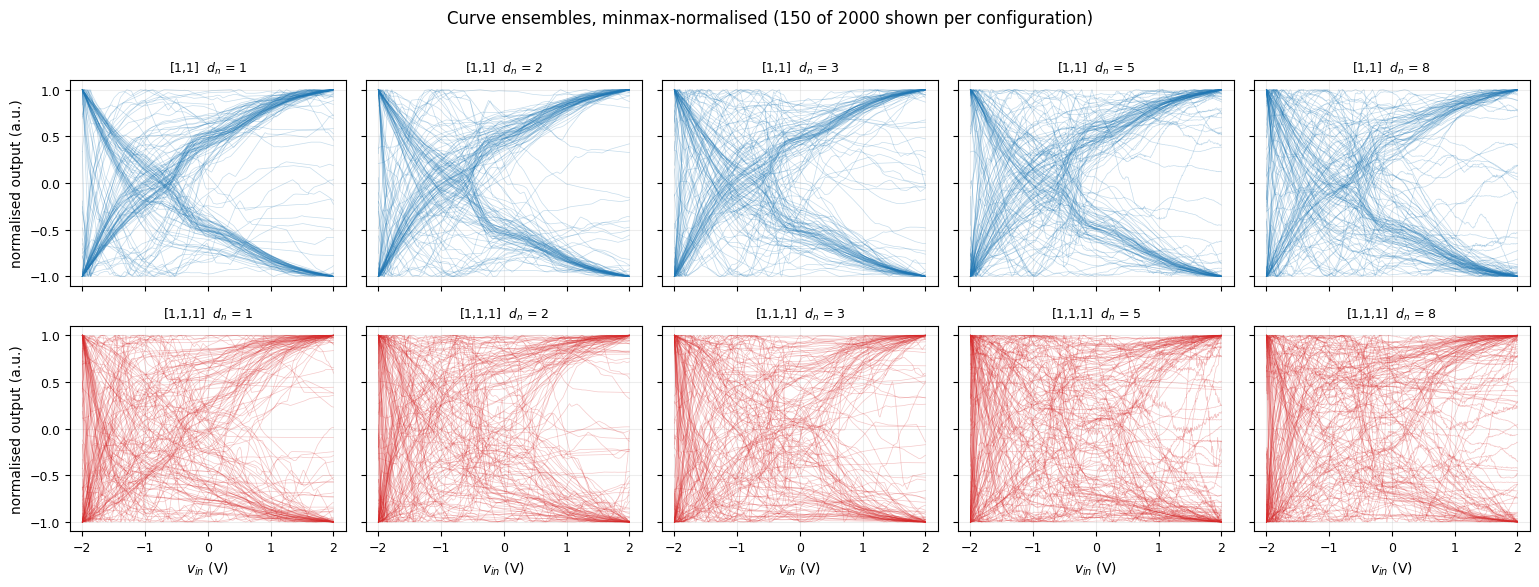

[fig] C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\DaCleanOnes\results_expressivity_release\figures\F1_curve_ensembles.png


In [11]:
# One panel per configuration, a sample of curves each. Rows are architectures,
# columns device counts, so reading across a row shows what adding devices does
# and reading down a column shows what adding a layer does. Only
# PLOT_SYNE_COUNTS is drawn; every configuration is still in the tables.
N_CURVES_TO_SHOW = 150
ARCHITECTURE_LABELS = [architecture_label(a) for a in ARCHITECTURES]
fig, axes = plt.subplots(len(ARCHITECTURE_LABELS), len(PLOT_SYNE_COUNTS),
                         figsize=(3.1 * len(PLOT_SYNE_COUNTS), 2.9 * len(ARCHITECTURE_LABELS)),
                         sharex=True, sharey=True, squeeze=False)
rng = np.random.RandomState(0)
for i, a in enumerate(ARCHITECTURE_LABELS):
    for j, SYNEs_per_synapse in enumerate(PLOT_SYNE_COUNTS):
        ax = axes[i][j]
        Y = CURVES_BY_CONFIGURATION[(a, SYNEs_per_synapse)]
        for t in rng.choice(Y.shape[0], size=min(N_CURVES_TO_SHOW, Y.shape[0]), replace=False):
            ax.plot(INPUT_REFERENCE_V, Y[t], lw=0.5, alpha=0.25,
                    color="tab:blue" if i == 0 else "tab:red")
        ax.set_title(f"{a}  $d_n$ = {SYNEs_per_synapse}", fontsize=9)
        ax.grid(alpha=GRID_ALPHA)
        if i == len(ARCHITECTURE_LABELS) - 1:
            ax.set_xlabel("$v_{in}$ (V)")
        if j == 0:
            ax.set_ylabel("normalised output (a.u.)")
fig.suptitle(f"Curve ensembles, {CURVE_NORMALISATION}-normalised "
             f"({N_CURVES_TO_SHOW} of {CURVES_PER_CONFIGURATION} shown per configuration)", y=1.005)
fig.tight_layout()
save_figure(fig, FIGURE_ROOT / "F1_curve_ensembles.png")
save_figure(fig, FIGURE_ROOT / "F1_curve_ensembles.pdf")
plt.show()
print("[fig]", FIGURE_ROOT / "F1_curve_ensembles.png")

## Shared PCA basis

A single PCA basis is fitted to a balanced pool of curves from every configuration. All $\epsilon$-packing distances are therefore measured in the same coordinate system.

The analysis retains the first `PCA_RANK` components. The full singular-value spectrum is also saved so the retained explained variance can be checked directly.

In [12]:
def fit_shared_pca(pool):
    """Fit one PCA basis to the balanced pooled curve ensemble."""
    curves = np.concatenate(pool, axis=0).astype(np.float64)
    n_samples = curves.shape[0]
    mean_curve = curves.mean(axis=0)
    _, singular_values, V_transpose = np.linalg.svd(
        curves - mean_curve,
        full_matrices=False,
    )
    eigenvalues = np.clip(
        singular_values ** 2 / (n_samples - 1),
        0.0,
        None,
    )
    total_variance = float(eigenvalues.sum())
    if total_variance > 0:
        explained_variance_ratio = eigenvalues / total_variance
    else:
        explained_variance_ratio = np.zeros_like(eigenvalues)
    return (
        mean_curve.astype(np.float32),
        V_transpose.T.astype(np.float32),
        eigenvalues,
        explained_variance_ratio,
        total_variance,
    )


def project(curves, mean_curve, basis, rank):
    """Project curves onto the first `rank` components of the shared basis."""
    curves_tensor = torch.from_numpy(np.asarray(curves, dtype=np.float32))
    mean_tensor = torch.from_numpy(np.asarray(mean_curve, dtype=np.float32))
    basis_tensor = torch.from_numpy(
        np.asarray(basis[:, :rank], dtype=np.float32)
    )
    return (curves_tensor - mean_tensor.unsqueeze(0)) @ basis_tensor


def participation_ratio(eigenvalues):
    first_moment = float(np.sum(eigenvalues))
    second_moment = float(np.sum(eigenvalues ** 2))
    if second_moment <= 0:
        return 0.0
    return first_moment ** 2 / second_moment


rng = np.random.RandomState(PCA_SEED)
PCA_POOL = []
for key in CONFIGURATION_KEYS:
    curves = CURVES_BY_CONFIGURATION[key]
    n_pool = min(PCA_CURVES_PER_CONFIGURATION, curves.shape[0])
    indices = rng.choice(curves.shape[0], size=n_pool, replace=False)
    PCA_POOL.append(curves[indices])

PCA_MEAN, PCA_BASIS, PCA_EIGENVALUES, PCA_EVR, PCA_TOTAL_VARIANCE = fit_shared_pca(
    PCA_POOL
)
PCA_RETAINED_RANK = min(PCA_RANK, int(INPUT_REFERENCE_V.size))
PCA_CUMULATIVE_EVR = np.cumsum(PCA_EVR) * 100.0

print(
    f"Pooled {sum(curves.shape[0] for curves in PCA_POOL)} curves | "
    f"basis {PCA_BASIS.shape} | retained rank {PCA_RETAINED_RANK}"
)
print(
    f"EVR at rank {PCA_RETAINED_RANK}: "
    f"{PCA_CUMULATIVE_EVR[PCA_RETAINED_RANK - 1]:.4f}%"
)
print(
    "Components for 90% / 99% EVR:",
    int(np.searchsorted(PCA_CUMULATIVE_EVR, 90.0) + 1),
    "/",
    int(np.searchsorted(PCA_CUMULATIVE_EVR, 99.0) + 1),
)
print("Participation ratio:", f"{participation_ratio(PCA_EIGENVALUES):.3f}")

np.savez_compressed(
    ARRAY_ROOT / "shared_pca_basis.npz",
    input_voltage=INPUT_REFERENCE_V.astype(np.float32),
    mean=PCA_MEAN,
    basis=PCA_BASIS,
    eigenvalues=PCA_EIGENVALUES,
    explained_variance_ratio=PCA_EVR,
    total_variance=np.array([PCA_TOTAL_VARIANCE]),
)

pd.DataFrame(
    {
        "component": np.arange(1, PCA_EIGENVALUES.size + 1),
        "eigenvalue": PCA_EIGENVALUES,
        "explained_variance_percent": 100.0 * PCA_EVR,
        "cumulative_explained_variance_percent": PCA_CUMULATIVE_EVR,
    }
).to_csv(TABLE_ROOT / "scree.csv", index=False)

print("Saved:", ARRAY_ROOT / "shared_pca_basis.npz")
print("Saved:", TABLE_ROOT / "scree.csv")

Pooled 8400 curves | basis (600, 600) | retained rank 32
EVR at rank 32: 99.9796%
Components for 90% / 99% EVR: 2 / 7
Participation ratio: 1.684
Saved: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\DaCleanOnes\results_expressivity_release\arrays\shared_pca_basis.npz
Saved: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\DaCleanOnes\results_expressivity_release\tables\scree.csv


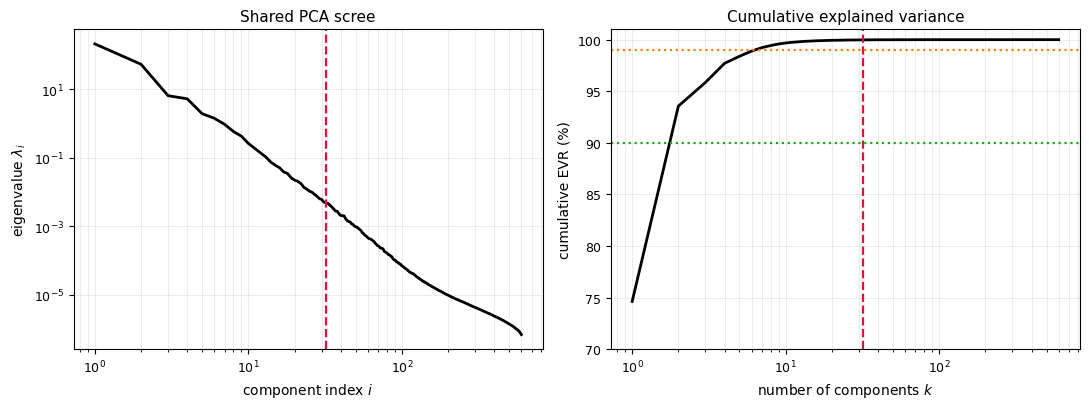

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))

component_index = np.arange(1, PCA_EIGENVALUES.size + 1)
axes[0].loglog(
    component_index,
    np.clip(PCA_EIGENVALUES, 1e-300, None),
    "k-",
    lw=2,
)
axes[0].axvline(PCA_RETAINED_RANK, color="crimson", ls="--", lw=1.6)
axes[0].set_xlabel("component index $i$")
axes[0].set_ylabel(r"eigenvalue $\lambda_i$")
axes[0].set_title("Shared PCA scree")

axes[1].semilogx(component_index, PCA_CUMULATIVE_EVR, "k-", lw=2)
axes[1].axvline(PCA_RETAINED_RANK, color="crimson", ls="--", lw=1.6)
axes[1].axhline(99, color="tab:orange", ls=":", lw=1.6)
axes[1].axhline(90, color="tab:green", ls=":", lw=1.6)
axes[1].set_ylim(min(70.0, PCA_CUMULATIVE_EVR[0] - 1.0), 101.0)
axes[1].set_xlabel("number of components $k$")
axes[1].set_ylabel("cumulative EVR (%)")
axes[1].set_title("Cumulative explained variance")

for axis in axes:
    axis.grid(alpha=GRID_ALPHA, which="both")

fig.tight_layout()
save_figure(fig, FIGURE_ROOT / "F2_shared_pca_scree.png")
save_figure(fig, FIGURE_ROOT / "F2_shared_pca_scree.pdf")
plt.show()

## $\epsilon$-packing

For a given radius $\epsilon$, the greedy packing routine keeps a subset of curves separated by more than $\epsilon$. The best result over several random orders is used because greedy packing is order dependent.

$\epsilon_{50}$ is the distance at which the packing number falls to half the retained curve count. The 95% packing distance measures the near-neighbour scale, while $\epsilon_{50}$ measures the bulk spacing of the reachable set.

In [14]:
@torch.no_grad()
def greedy_packing_count(distances, epsilon, order):
    available = torch.ones(
        distances.shape[0],
        dtype=torch.bool,
        device=distances.device,
    )
    count = 0
    for index in order:
        index = int(index)
        if available[index]:
            count += 1
            available &= distances[index] > epsilon
            available[index] = False
    return int(count)


@torch.no_grad()
def packing_counts(
    distances,
    epsilon_values,
    seed,
    n_restarts=PACKING_RESTARTS,
):
    n_curves = distances.shape[0]
    rng = np.random.RandomState(seed)
    orders = [
        rng.permutation(n_curves).astype(np.int64)
        for _ in range(n_restarts)
    ]

    best_counts = []
    mean_counts = []
    for epsilon in np.atleast_1d(epsilon_values):
        counts = [
            greedy_packing_count(distances, float(epsilon), order)
            for order in orders
        ]
        best_counts.append(int(np.max(counts)))
        mean_counts.append(float(np.mean(counts)))

    return (
        np.asarray(best_counts, dtype=np.int32),
        np.asarray(mean_counts, dtype=np.float64),
    )


@torch.no_grad()
def pairwise_distances(points):
    return torch.cdist(points, points)


def median_distance(distances, max_curves=1200, seed=0):
    n_curves = distances.shape[0]
    if n_curves > max_curves:
        sampled_indices = np.random.RandomState(seed).choice(
            n_curves,
            size=max_curves,
            replace=False,
        ).astype(np.int64, copy=False)
        indices = torch.as_tensor(
            sampled_indices,
            dtype=torch.long,
            device=distances.device,
        )
        sampled = distances[indices][:, indices]
    else:
        sampled = distances

    n_sampled = sampled.shape[0]
    upper = torch.triu_indices(
        n_sampled,
        n_sampled,
        offset=1,
        device=sampled.device,
    )
    values = sampled[upper[0], upper[1]]
    values = values[values > 0]
    if values.numel() == 0:
        return 0.0
    return float(values.median().item())


def find_packing_distance(
    distances,
    low,
    high,
    seed,
    fraction=0.5,
    n_restarts=PACKING_RESTARTS,
    iterations=EPS50_BISECTION_STEPS,
):
    target = fraction * distances.shape[0]
    low = float(low)
    high = float(high)
    for _ in range(iterations):
        midpoint = 0.5 * (low + high)
        best, _ = packing_counts(
            distances,
            [midpoint],
            seed,
            n_restarts=n_restarts,
        )
        if best[0] > target:
            low = midpoint
        else:
            high = midpoint
    return 0.5 * (low + high)


def distance_extremes(distances):
    n_curves = distances.shape[0]
    upper = torch.triu_indices(
        n_curves,
        n_curves,
        offset=1,
        device=distances.device,
    )
    values = distances[upper[0], upper[1]]
    values = values[torch.isfinite(values) & (values > 0)]
    return float(values.min().item()), float(values.max().item())


def packing_curve(
    distances,
    epsilon_grid,
    minimum_distance,
    diameter,
    seed,
    n_restarts=PACKING_RESTARTS,
):
    n_curves = int(distances.shape[0])
    best = np.empty(epsilon_grid.size, dtype=np.int64)
    mean = np.empty(epsilon_grid.size, dtype=np.float64)

    middle = (epsilon_grid >= minimum_distance) & (epsilon_grid < diameter)
    best[epsilon_grid < minimum_distance] = n_curves
    mean[epsilon_grid < minimum_distance] = float(n_curves)
    best[epsilon_grid >= diameter] = 1
    mean[epsilon_grid >= diameter] = 1.0

    if middle.any():
        best_middle, mean_middle = packing_counts(
            distances,
            epsilon_grid[middle],
            seed,
            n_restarts=n_restarts,
        )
        best[middle] = best_middle
        mean[middle] = mean_middle

    return best, mean


def soft_diameter(distance_values, tau):
    return float(tau * torch.logsumexp(distance_values / tau, dim=0))


def upper_triangle(distances):
    n_curves = distances.shape[0]
    upper = torch.triu_indices(
        n_curves,
        n_curves,
        offset=1,
        device=distances.device,
    )
    return distances[upper[0], upper[1]]

In [15]:
GRID_PAD_LOW = 0.5
GRID_PAD_HIGH = 1.2

DISTANCES_BY_CONFIGURATION = {}
DISTANCE_EXTREMES = {}
MEDIAN_DISTANCE_BY_CONFIGURATION = {}

for key in CONFIGURATION_KEYS:
    projected_curves = project(
        CURVES_BY_CONFIGURATION[key],
        PCA_MEAN,
        PCA_BASIS,
        PCA_RETAINED_RANK,
    )
    distances = pairwise_distances(projected_curves)
    DISTANCES_BY_CONFIGURATION[key] = distances
    DISTANCE_EXTREMES[key] = distance_extremes(distances)
    MEDIAN_DISTANCE_BY_CONFIGURATION[key] = median_distance(
        distances,
        seed=int(PACKING_SEED + 7 * key[1]),
    )

    minimum_distance, diameter = DISTANCE_EXTREMES[key]
    print(
        f"  {key[0]:8s} | SYNEs/synapse {key[1]:2d} | "
        f"minimum pair {minimum_distance:.4e} | diameter {diameter:.4e}"
    )

n_pairs = CURVES_PER_CONFIGURATION * (CURVES_PER_CONFIGURATION - 1) // 2
pooled_median_distance = float(
    np.exp(
        np.mean(
            np.log(
                np.clip(
                    list(MEDIAN_DISTANCE_BY_CONFIGURATION.values()),
                    1e-30,
                    None,
                )
            )
        )
    )
)
print(
    f"\nSoft-diameter tau: {SOFT_DIAMETER_TAU:g} "
    f"({SOFT_DIAMETER_TAU / pooled_median_distance:.4f} x pooled median distance)"
)
print(
    "Maximum tau*log(n_pairs) over-estimate:",
    f"{SOFT_DIAMETER_TAU * np.log(n_pairs):.3f}",
)

EPSILON_GRID_LOW = GRID_PAD_LOW * min(
    values[0] for values in DISTANCE_EXTREMES.values()
)
EPSILON_GRID_HIGH = GRID_PAD_HIGH * max(
    values[1] for values in DISTANCE_EXTREMES.values()
)
EPSILON_GRID = np.geomspace(
    EPSILON_GRID_LOW,
    EPSILON_GRID_HIGH,
    num=N_EPSILON,
).astype(np.float64)

print(
    f"Shared epsilon grid: {N_EPSILON} radii | "
    f"{EPSILON_GRID_LOW:.3e} -> {EPSILON_GRID_HIGH:.3e}"
)

  [1,1]    | SYNEs/synapse  1 | minimum pair 6.2255e-02 | diameter 4.4251e+01
  [1,1]    | SYNEs/synapse  2 | minimum pair 9.3260e-02 | diameter 4.4202e+01
  [1,1]    | SYNEs/synapse  3 | minimum pair 1.8521e-01 | diameter 4.3605e+01
  [1,1]    | SYNEs/synapse  4 | minimum pair 1.9531e-01 | diameter 4.4376e+01
  [1,1]    | SYNEs/synapse  5 | minimum pair 2.6591e-01 | diameter 4.3107e+01
  [1,1]    | SYNEs/synapse  6 | minimum pair 2.1721e-01 | diameter 4.3732e+01
  [1,1]    | SYNEs/synapse  8 | minimum pair 2.5116e-01 | diameter 4.3364e+01
  [1,1,1]  | SYNEs/synapse  1 | minimum pair 3.1907e-01 | diameter 4.7732e+01
  [1,1,1]  | SYNEs/synapse  2 | minimum pair 4.7467e-01 | diameter 4.7804e+01
  [1,1,1]  | SYNEs/synapse  3 | minimum pair 4.2166e-01 | diameter 4.7174e+01
  [1,1,1]  | SYNEs/synapse  4 | minimum pair 4.5397e-01 | diameter 4.6663e+01
  [1,1,1]  | SYNEs/synapse  5 | minimum pair 4.9685e-01 | diameter 4.7045e+01
  [1,1,1]  | SYNEs/synapse  6 | minimum pair 4.9614e-01 | diamet

In [16]:
PACKING_CURVE_ROWS = []
PACKING_SUMMARY = []
EPS50_BY_CONFIGURATION = {}
HIGH_PACKING_DISTANCE_BY_CONFIGURATION = {}
SOFT_DIAMETER_BY_CONFIGURATION = {}

for key in CONFIGURATION_KEYS:
    started = time.time()
    seed = int(PACKING_SEED + 1000 * key[1] + 17 * len(key[0]))
    distances = DISTANCES_BY_CONFIGURATION[key]
    minimum_distance, diameter = DISTANCE_EXTREMES[key]

    best_counts, mean_counts = packing_curve(
        distances,
        EPSILON_GRID,
        minimum_distance,
        diameter,
        seed,
    )
    for epsilon, best, mean in zip(
        EPSILON_GRID,
        best_counts,
        mean_counts,
    ):
        PACKING_CURVE_ROWS.append(
            {
                "architecture": key[0],
                "SYNEs_per_synapse": key[1],
                "epsilon": float(epsilon),
                "packing_best": int(best),
                "packing_mean": float(mean),
            }
        )

    median = MEDIAN_DISTANCE_BY_CONFIGURATION[key]
    eps50 = find_packing_distance(
        distances,
        low=1e-3 * median,
        high=1.5 * diameter,
        seed=seed,
        fraction=0.5,
    )
    eps_high = find_packing_distance(
        distances,
        low=1e-4 * median,
        high=1.5 * diameter,
        seed=seed,
        fraction=HIGH_PACKING_FRACTION,
    )
    soft = soft_diameter(upper_triangle(distances), SOFT_DIAMETER_TAU)

    EPS50_BY_CONFIGURATION[key] = eps50
    HIGH_PACKING_DISTANCE_BY_CONFIGURATION[key] = eps_high
    SOFT_DIAMETER_BY_CONFIGURATION[key] = soft

    n_curves = int(distances.shape[0])
    below_half = np.nonzero(np.asarray(best_counts) <= n_curves / 2)[0]
    eps50_from_grid = (
        float(EPSILON_GRID[below_half[0]])
        if below_half.size
        else float("nan")
    )

    PACKING_SUMMARY.append(
        {
            "architecture": key[0],
            "SYNEs_per_synapse": int(key[1]),
            "K": n_curves,
            "median_distance": float(median),
            "diameter": float(diameter),
            "eps50": float(eps50),
            "eps50_from_grid": eps50_from_grid,
            "eps_hi": float(eps_high),
            "soft_diameter": float(soft),
        }
    )

    print(
        f"  {key[0]:8s} | SYNEs/synapse {key[1]:2d} | "
        f"eps50 {eps50:.6e} | "
        f"eps{int(100 * HIGH_PACKING_FRACTION)} {eps_high:.4e} | "
        f"soft diameter {soft:.4f} | {time.time() - started:.1f} s"
    )

pd.DataFrame(PACKING_CURVE_ROWS).to_csv(
    TABLE_ROOT / "packing_curves.csv",
    index=False,
)
print("Saved:", TABLE_ROOT / "packing_curves.csv")

  [1,1]    | SYNEs/synapse  1 | eps50 7.162073e-01 | eps95 2.1615e-01 | soft diameter 45.1604 | 21.3 s
  [1,1]    | SYNEs/synapse  2 | eps50 1.198327e+00 | eps95 3.7167e-01 | soft diameter 44.8873 | 23.6 s
  [1,1]    | SYNEs/synapse  3 | eps50 1.306926e+00 | eps95 4.5805e-01 | soft diameter 44.3036 | 18.1 s
  [1,1]    | SYNEs/synapse  4 | eps50 1.332439e+00 | eps95 4.8128e-01 | soft diameter 44.7010 | 18.0 s
  [1,1]    | SYNEs/synapse  5 | eps50 1.407937e+00 | eps95 4.9055e-01 | soft diameter 43.7473 | 16.4 s
  [1,1]    | SYNEs/synapse  6 | eps50 1.477272e+00 | eps95 5.1229e-01 | soft diameter 44.2536 | 18.7 s
  [1,1]    | SYNEs/synapse  8 | eps50 1.478334e+00 | eps95 5.5234e-01 | soft diameter 43.7023 | 17.3 s
  [1,1,1]  | SYNEs/synapse  1 | eps50 1.897059e+00 | eps95 7.5233e-01 | soft diameter 48.2417 | 18.9 s
  [1,1,1]  | SYNEs/synapse  2 | eps50 2.342570e+00 | eps95 9.1010e-01 | soft diameter 48.1621 | 17.3 s
  [1,1,1]  | SYNEs/synapse  3 | eps50 2.574744e+00 | eps95 1.0334e+00 | s

In [17]:
eps50_geometric_mean = float(
    np.exp(
        np.mean(
            np.log(
                [EPS50_BY_CONFIGURATION[key] for key in CONFIGURATION_KEYS]
            )
        )
    )
)

for row in PACKING_SUMMARY:
    row["eps50_set_relative"] = row["eps50"] / eps50_geometric_mean
    row["n_layers"] = row["architecture"].count(",")
    row["trainable_parameters"] = row["n_layers"] * (
        5 * row["SYNEs_per_synapse"] + 1
    )
    row["total_devices"] = row["n_layers"] * row["SYNEs_per_synapse"]
    row["in_plot"] = int(row["SYNEs_per_synapse"] in PLOT_SYNE_COUNTS)
    row["in_fit"] = int(row["SYNEs_per_synapse"] in FIT_SYNE_COUNTS)

packing_summary_table = pd.DataFrame(PACKING_SUMMARY)
packing_summary_table.to_csv(TABLE_ROOT / "eps50.csv", index=False)

display(
    packing_summary_table.set_index(["architecture", "SYNEs_per_synapse"])
)

ARCHITECTURE_LABELS = [architecture_label(value) for value in ARCHITECTURES]
if len(ARCHITECTURE_LABELS) == 2:
    depth_ratio_rows = []
    for SYNEs_per_synapse in SYNE_COUNTS:
        shallow_key = (ARCHITECTURE_LABELS[0], SYNEs_per_synapse)
        deep_key = (ARCHITECTURE_LABELS[1], SYNEs_per_synapse)
        if shallow_key not in EPS50_BY_CONFIGURATION or deep_key not in EPS50_BY_CONFIGURATION:
            continue
        shallow_eps50 = EPS50_BY_CONFIGURATION[shallow_key]
        deep_eps50 = EPS50_BY_CONFIGURATION[deep_key]
        depth_ratio_rows.append(
            {
                "SYNEs_per_synapse": SYNEs_per_synapse,
                "eps50_shallow": shallow_eps50,
                "eps50_deep": deep_eps50,
                "ratio_deep_over_shallow": deep_eps50 / shallow_eps50,
            }
        )

    pd.DataFrame(depth_ratio_rows).to_csv(
        TABLE_ROOT / "depth_ratio.csv",
        index=False,
    )

print("Saved:", TABLE_ROOT / "eps50.csv")

K  median_distance   diameter     eps50  \
architecture SYNEs_per_synapse                                               
[1,1]        1                  2000        22.220884  44.250904  0.716207   
             2                  2000        22.127066  44.202202  1.198327   
             3                  2000        21.377256  43.605125  1.306926   
             4                  2000        21.352468  44.376347  1.332439   
             5                  2000        21.569000  43.106720  1.407937   
             6                  2000        21.059603  43.732433  1.477272   
             8                  2000        21.469738  43.364086  1.478334   
[1,1,1]      1                  2000        23.638720  47.732059  1.897059   
             2                  2000        23.403425  47.803978  2.342570   
             3                  2000        22.740288  47.174374  2.574744   
             4                  2000        22.708942  46.663063  2.653513   
             5                  2000        22.945583  47.045414  2.758358   
             6                  2000        22.880730  47.728710  2.875507   
             8                  2000        22.335772  47.214325  2.887696   

                                eps50_from_grid    eps_hi  soft_diameter  \
architecture SYNEs_per_synapse                                             
[1,1]        1                         0.732748  0.216150      45.160442   
             2                         1.226362  0.371671      44.887329   
             3                         1.313532  0.458049      44.303585   
             4                         1.359413  0.481281      44.701004   
             5                         1.456041  0.490548      43.747303   
             6                         1.506900  0.512288      44.253601   
             8                         1.506900  0.552337      43.702297   
[1,1,1]      1                         1.916289  0.752332      48.241730   
             2                         2.354652  0.910102      48.162117   
             3                         2.610115  1.033431      47.544182   
             4                         2.701286  1.039923      47.066830   
             5                         2.795642  1.034182      47.364727   
             6                         2.893294  1.082515      47.863800   
             8                         2.893294  1.090693      47.525909   

                                eps50_set_relative  n_layers  \
architecture SYNEs_per_synapse                                 
[1,1]        1                            0.402450         1   
             2                            0.673362         1   
             3                            0.734386         1   
             4                            0.748722         1   
             5                            0.791146         1   
             6                            0.830107         1   
             8                            0.830703         1   
[1,1,1]      1                            1.065992         2   
             2                            1.316333         2   
             3                            1.446796         2   
             4                            1.491058         2   
             5                            1.549972         2   
             6                            1.615800         2   
             8                            1.622650         2   

                                trainable_parameters  total_devices  in_plot  \
architecture SYNEs_per_synapse                                                 
[1,1]        1                                     6              1        1   
             2                                    11              2        1   
             3                                    16              3        1   
             4                                    21              4        0   
             5                                    26            

Saved: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\DaCleanOnes\results_expressivity_release\tables\eps50.csv


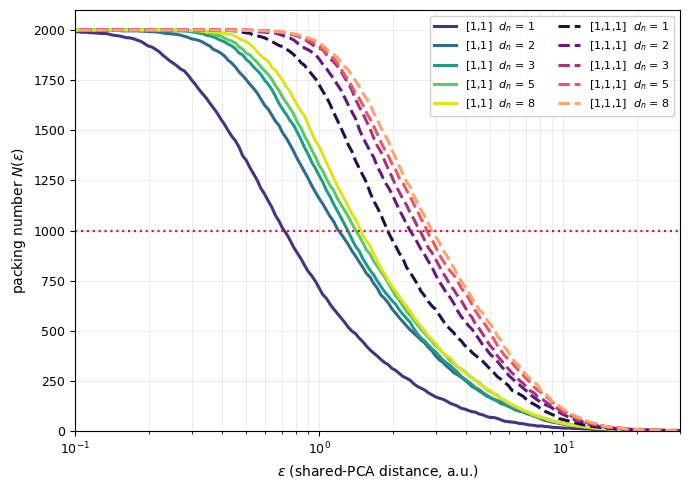

In [23]:
SHALLOW_COLOURMAP = plt.get_cmap("viridis")
DEEP_COLOURMAP = plt.get_cmap("magma")
PLOT_CONFIGURATION_KEYS = [
    key for key in CONFIGURATION_KEYS if key[1] in PLOT_SYNE_COUNTS
]


def configuration_colour(key):
    position = PLOT_SYNE_COUNTS.index(key[1])
    if len(PLOT_SYNE_COUNTS) == 1:
        fraction = 0.0
    else:
        fraction = position / (len(PLOT_SYNE_COUNTS) - 1)
    shade = 0.15 + 0.8 * fraction
    if key[0] == ARCHITECTURE_LABELS[0]:
        return SHALLOW_COLOURMAP(shade)
    return DEEP_COLOURMAP(0.85 * shade)


packing_curve_table = pd.DataFrame(PACKING_CURVE_ROWS)
fig, ax = plt.subplots(figsize=(7.0, 5.0))
for key in PLOT_CONFIGURATION_KEYS:
    selected = packing_curve_table[
        (packing_curve_table["architecture"] == key[0])
        & (packing_curve_table["SYNEs_per_synapse"] == key[1])
    ].sort_values("epsilon")
    ax.plot(
        selected["epsilon"],
        selected["packing_best"],
        color=configuration_colour(key),
        lw=2.2,
        ls="-" if key[0] == ARCHITECTURE_LABELS[0] else "--",
        label=f"{key[0]}  $d_n$ = {key[1]}",
    )

ax.axhline(
    CURVES_PER_CONFIGURATION / 2,
    color="crimson",
    ls=":",
    lw=1.6,
)
ax.set_xscale("log")
ax.set_xlim(1e-1, 30)
ax.set_ylim(0, CURVES_PER_CONFIGURATION * 1.05)
ax.set_xlabel(r"$\epsilon$ (shared-PCA distance, a.u.)")
ax.set_ylabel(r"packing number $N(\epsilon)$")
ax.grid(alpha=GRID_ALPHA, which="both")
ax.legend(fontsize=8, ncol=2, framealpha=0.9)
fig.tight_layout()
save_figure(fig, FIGURE_ROOT / "F3_packing_curves.png")
save_figure(fig, FIGURE_ROOT / "F3_packing_curves.pdf")
plt.show()

## $\epsilon_{50}$ scaling with trainable parameters

The same packing result can be read against the number of trainable physical KAN parameters. The fit uses the selected `FIT_SYNE_COUNTS` values for each architecture.

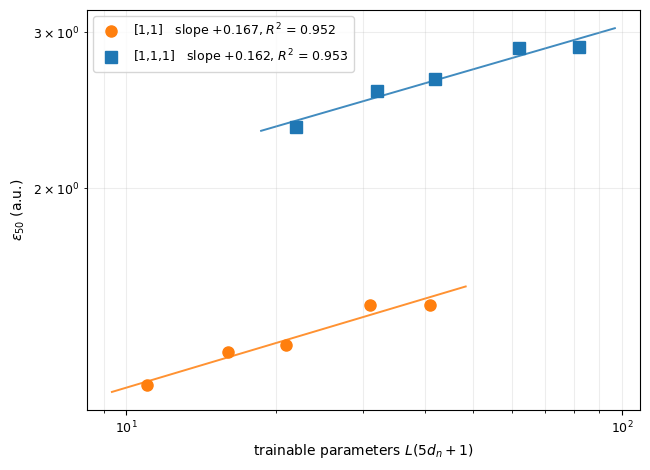

In [19]:
def log_log_fit(x, y):
    """Fit y = A*x^b in log space and return b, log10(A), R^2."""
    log_x = np.log10(np.asarray(x, dtype=float))
    log_y = np.log10(np.asarray(y, dtype=float))
    design = np.vstack([log_x, np.ones_like(log_x)]).T
    coefficients, *_ = np.linalg.lstsq(design, log_y, rcond=None)
    residual = log_y - design @ coefficients
    total = float(((log_y - log_y.mean()) ** 2).sum())
    r_squared = (
        1.0 - float((residual ** 2).sum()) / total
        if total > 0
        else float("nan")
    )
    return float(coefficients[0]), float(coefficients[1]), r_squared


def plot_power_law_fit(axis, x, y, colour):
    slope, intercept, r_squared = log_log_fit(x, y)
    fit_x = np.geomspace(min(x) * 0.85, max(x) * 1.18, 50)
    axis.plot(
        fit_x,
        10 ** intercept * fit_x ** slope,
        "-",
        color=colour,
        lw=1.4,
        alpha=0.85,
        zorder=1,
    )
    return slope, r_squared


ARCHITECTURE_COLOUR = {
    ARCHITECTURE_LABELS[0]: "C1",
    ARCHITECTURE_LABELS[1]: "C0",
}
SCALING_FIT_ROWS = []

fig, ax = plt.subplots(figsize=(6.6, 4.8))
for architecture, marker in zip(ARCHITECTURE_LABELS, ("o", "s")):
    selected = sorted(
        [
            row for row in PACKING_SUMMARY
            if row["architecture"] == architecture
            and row["SYNEs_per_synapse"] in FIT_SYNE_COUNTS
        ],
        key=lambda row: row["trainable_parameters"],
    )
    x = [row["trainable_parameters"] for row in selected]
    y = [row["eps50"] for row in selected]
    slope, r_squared = plot_power_law_fit(
        ax,
        x,
        y,
        ARCHITECTURE_COLOUR[architecture],
    )
    ax.plot(
        x,
        y,
        marker,
        ms=8,
        color=ARCHITECTURE_COLOUR[architecture],
        zorder=3,
        label=f"{architecture}   slope {slope:+.3f}, $R^2$ = {r_squared:.3f}",
    )
    SCALING_FIT_ROWS.append(
        ["eps50_vs_parameters", architecture, slope, r_squared]
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"trainable parameters $L(5d_n+1)$")
ax.set_ylabel(r"$\epsilon_{50}$ (a.u.)")
ax.grid(alpha=GRID_ALPHA, which="both")
ax.legend(fontsize=9)
fig.tight_layout()
save_figure(fig, FIGURE_ROOT / "F4_eps50_vs_params.png")
save_figure(fig, FIGURE_ROOT / "F4_eps50_vs_params.pdf")
plt.show()

## $\epsilon_{50}$ against task error

The table below contains the simulation test MSE used for the expressivity comparison at `SYNEs_per_synapse = 2, 3, 4, 6, 8`. Larger $\epsilon_{50}$ should correspond to lower task error if the packing metric captures useful reachable-set diversity.

In [20]:
SIMULATION_MSE_DATA = {
    "index": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    "architecture": [
        "1-1-1", "1-1-1", "1-1-1", "1-1-1", "1-1-1",
        "1-1", "1-1", "1-1", "1-1", "1-1"
    ],
    "SYNEs_per_synapse": [2, 3, 4, 6, 8, 2, 3, 4, 6, 8],
    "mse_loss": [
        0.005881, 0.001807, 0.001099, 0.000416, 0.000247,
        0.017463, 0.010349, 0.006550, 0.004128, 0.004226
    ],
    "completed_functions": [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
}


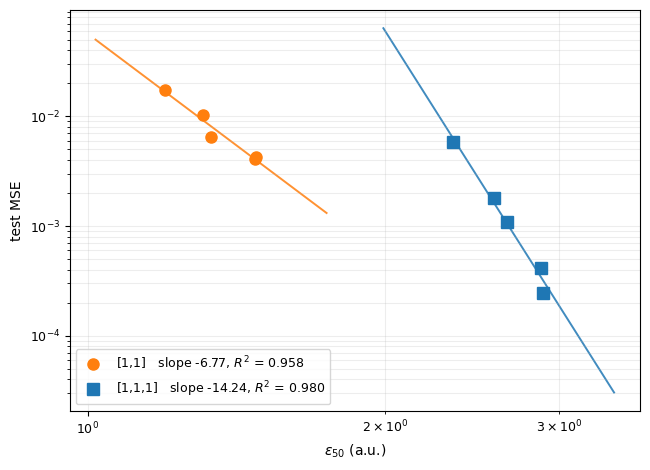

In [21]:
ARCHITECTURE_FROM_DASH = {
    "1-1": "[1,1]",
    "1-1-1": "[1,1,1]",
}
MSE_BY_CONFIGURATION = {
    (ARCHITECTURE_FROM_DASH[architecture], int(SYNEs_per_synapse)): float(mse)
    for architecture, SYNEs_per_synapse, mse in zip(
        SIMULATION_MSE_DATA["architecture"],
        SIMULATION_MSE_DATA["SYNEs_per_synapse"],
        SIMULATION_MSE_DATA["mse_loss"],
    )
}
EPS50_LOOKUP = {
    (row["architecture"], row["SYNEs_per_synapse"]): row["eps50"]
    for row in PACKING_SUMMARY
}
missing = [key for key in MSE_BY_CONFIGURATION if key not in EPS50_LOOKUP]
if missing:
    raise RuntimeError(f"No eps50 value was measured for: {missing}")

fig, ax = plt.subplots(figsize=(6.6, 4.8))
for architecture, marker in zip(ARCHITECTURE_LABELS, ("o", "s")):
    points = sorted(
        [
            (EPS50_LOOKUP[key], MSE_BY_CONFIGURATION[key])
            for key in MSE_BY_CONFIGURATION
            if key[0] == architecture
        ]
    )
    x = [point[0] for point in points]
    y = [point[1] for point in points]
    slope, r_squared = plot_power_law_fit(
        ax,
        x,
        y,
        ARCHITECTURE_COLOUR[architecture],
    )
    ax.plot(
        x,
        y,
        marker,
        ms=8,
        color=ARCHITECTURE_COLOUR[architecture],
        zorder=3,
        label=f"{architecture}   slope {slope:+.2f}, $R^2$ = {r_squared:.3f}",
    )
    SCALING_FIT_ROWS.append(
        ["mse_vs_eps50", architecture, slope, r_squared]
    )

pooled_x = [EPS50_LOOKUP[key] for key in MSE_BY_CONFIGURATION]
pooled_y = [MSE_BY_CONFIGURATION[key] for key in MSE_BY_CONFIGURATION]
pooled_slope, _, pooled_r_squared = log_log_fit(pooled_x, pooled_y)
SCALING_FIT_ROWS.append(
    ["mse_vs_eps50", "pooled", pooled_slope, pooled_r_squared]
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\epsilon_{50}$ (a.u.)")
ax.set_ylabel("test MSE")
ax.grid(alpha=GRID_ALPHA, which="both")
ax.legend(fontsize=9)
fig.tight_layout()
save_figure(fig, FIGURE_ROOT / "F5_mse_vs_eps50.png")
save_figure(fig, FIGURE_ROOT / "F5_mse_vs_eps50.pdf")
plt.show()

## Reachable-set geometry against the device budget

The packing measures are also plotted against total physical devices, $L \times d_n$. This makes `[1,1]` with six SYNEs per synapse directly comparable with `[1,1,1]` with three SYNEs per synapse.

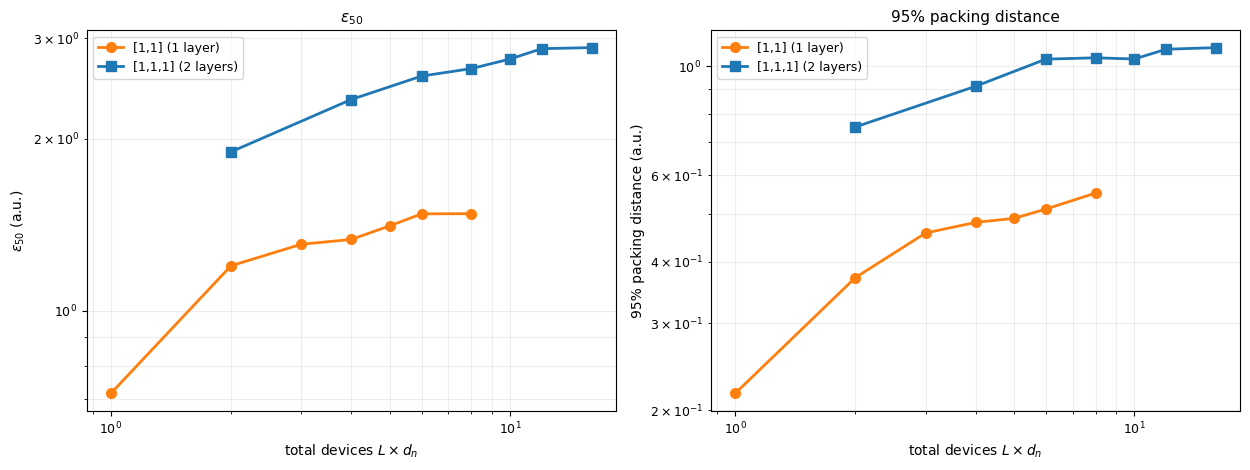

Saved: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\DaCleanOnes\results_expressivity_release\tables\scaling_fits.csv


In [22]:
MEASURES = [
    ("eps50", r"$\epsilon_{50}$ (a.u.)", r"$\epsilon_{50}$"),
    (
        "eps_hi",
        f"{int(100 * HIGH_PACKING_FRACTION)}% packing distance (a.u.)",
        f"{int(100 * HIGH_PACKING_FRACTION)}% packing distance",
    ),
]

fig, axes = plt.subplots(
    1,
    len(MEASURES),
    figsize=(6.0 * len(MEASURES) + 0.6, 4.8),
)
for axis, (field, y_label, title) in zip(np.atleast_1d(axes), MEASURES):
    for architecture, marker in zip(ARCHITECTURE_LABELS, ("o", "s")):
        selected = sorted(
            [row for row in PACKING_SUMMARY if row["architecture"] == architecture],
            key=lambda row: row["total_devices"],
        )
        n_layers = selected[0]["n_layers"]
        axis.plot(
            [row["total_devices"] for row in selected],
            [row[field] for row in selected],
            marker + "-",
            ms=7,
            lw=2.0,
            color=ARCHITECTURE_COLOUR[architecture],
            label=f"{architecture} ({n_layers} layer{'s' if n_layers > 1 else ''})",
        )
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel(r"total devices $L \times d_n$")
    axis.set_ylabel(y_label)
    axis.set_title(title)
    axis.grid(alpha=GRID_ALPHA, which="both")
    axis.legend(fontsize=9)

fig.tight_layout()
save_figure(fig, FIGURE_ROOT / "F6_packing_vs_devices.png")
save_figure(fig, FIGURE_ROOT / "F6_packing_vs_devices.pdf")
plt.show()

pd.DataFrame(
    SCALING_FIT_ROWS,
    columns=["relation", "architecture", "loglog_slope", "r2"],
).to_csv(TABLE_ROOT / "scaling_fits.csv", index=False)

print("Saved:", TABLE_ROOT / "scaling_fits.csv")

## Output files

Each run writes to `results_expressivity_release/` by default:

- `curves/`: retained raw and mean-subtracted response curves for every configuration;
- `arrays/curves_minmax.npz`: normalised curves used by the expressivity metric;
- `arrays/shared_pca_basis.npz`: the shared PCA basis and eigenvalue spectrum;
- `tables/generation_diagnostics.csv`: curve-generation and conditioning checks;
- `tables/scree.csv`: the full PCA eigenvalue spectrum;
- `tables/packing_curves.csv`: $N(\epsilon)$ for every configuration;
- `tables/eps50.csv`: $\epsilon_{50}$, the 95% packing distance and device/parameter counts;
- `tables/depth_ratio.csv`: deep/shallow $\epsilon_{50}$ ratios at matched SYNE count;
- `tables/scaling_fits.csv`: log-log scaling fits;
- `figures/`: the curve-ensemble, PCA, packing and scaling figures;
- `GENERATION_REPORT.json`: machine-readable generation metadata.